In [6]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import geopandas as gpd
import urllib.request
import zipfile

root_dir = Path.cwd().resolve()
if not (root_dir / "src").exists() and (root_dir / "notebooks").exists():
    root_dir = root_dir.parent

sys.path.insert(0, str(root_dir))
from src.config import TABLES_DIR, FIGURES_DIR

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Setup complete")

Setup complete


In [8]:
stats = pd.read_csv(TABLES_DIR / "district_prevalence.csv")
print(f"Stats loaded: {len(stats)} rows")
print(f"CSV columns: {list(stats.columns)}")

state_col = next(
    (c for c in stats.columns if c.lower() in {"v024", "state_code", "state_id", "state", "state_name"}),
    None,
)
if state_col is None:
    raise KeyError(f"No state column found in stats. Available columns: {list(stats.columns)}")
if state_col != "V024":
    stats = stats.rename(columns={state_col: "V024"})

if "is_aspirational" not in stats.columns:
    stats["is_aspirational"] = 0

state_stats = (
    stats.groupby("V024")
    .agg(
        stunting_prev=("stunting_prev", "mean"),
        underweight_prev=("underweight_prev", "mean"),
        wasting_prev=("wasting_prev", "mean"),
        is_aspirational=("is_aspirational", "max"),
    )
    .reset_index()
)
print(f"State-level stats: {len(state_stats)} states")
print(state_stats.head())


def load_india_districts():
    candidate_paths = [
        Path("../data/raw/shapefiles/gadm41_IND_2.shp"),
        Path("data/raw/shapefiles/gadm41_IND_2.shp"),
        Path.cwd().resolve() / "data/raw/shapefiles/gadm41_IND_2.shp",
    ]
    shapefile_path = next((p for p in candidate_paths if p.exists() and p.with_suffix(".shx").exists()), None)

    if shapefile_path is None:
        shapefile_dir = Path("data/raw/shapefiles")
        shapefile_dir.mkdir(parents=True, exist_ok=True)
        archive_path = shapefile_dir / "gadm41_IND_shp.zip"
        if not archive_path.exists():
            url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_IND_shp.zip"
            urllib.request.urlretrieve(url, archive_path)
        with zipfile.ZipFile(archive_path) as archive:
            archive.extractall(shapefile_dir)
        shapefile_path = next((p for p in candidate_paths if p.exists() and p.with_suffix(".shx").exists()), None)

    if shapefile_path is None:
        raise FileNotFoundError("India shapefile is missing or incomplete; cannot render a choropleth map.")

    districts = gpd.read_file(shapefile_path)
    print(f"Shapefile loaded: {len(districts)} districts")
    print(f"Columns: {list(districts.columns)}")
    return districts


districts = load_india_districts()

Stats loaded: 707 rows
CSV columns: ['V024', 'district_code', 'stunting_prev', 'underweight_prev', 'wasting_prev', 'mean_haz', 'mean_waz', 'mean_whz', 'n_children', 'is_aspirational']
State-level stats: 36 states
   V024  stunting_prev  underweight_prev  wasting_prev  is_aspirational
0     1       0.236750          0.198980      0.164995                0
1     2       0.291692          0.224367      0.139475                0
2     3       0.219695          0.154964      0.092641                0
3     4       0.218400          0.189700      0.086200                0
4     5       0.243392          0.169477      0.106369                0


Shapefile loaded: 676 districts
Columns: ['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2', 'geometry']


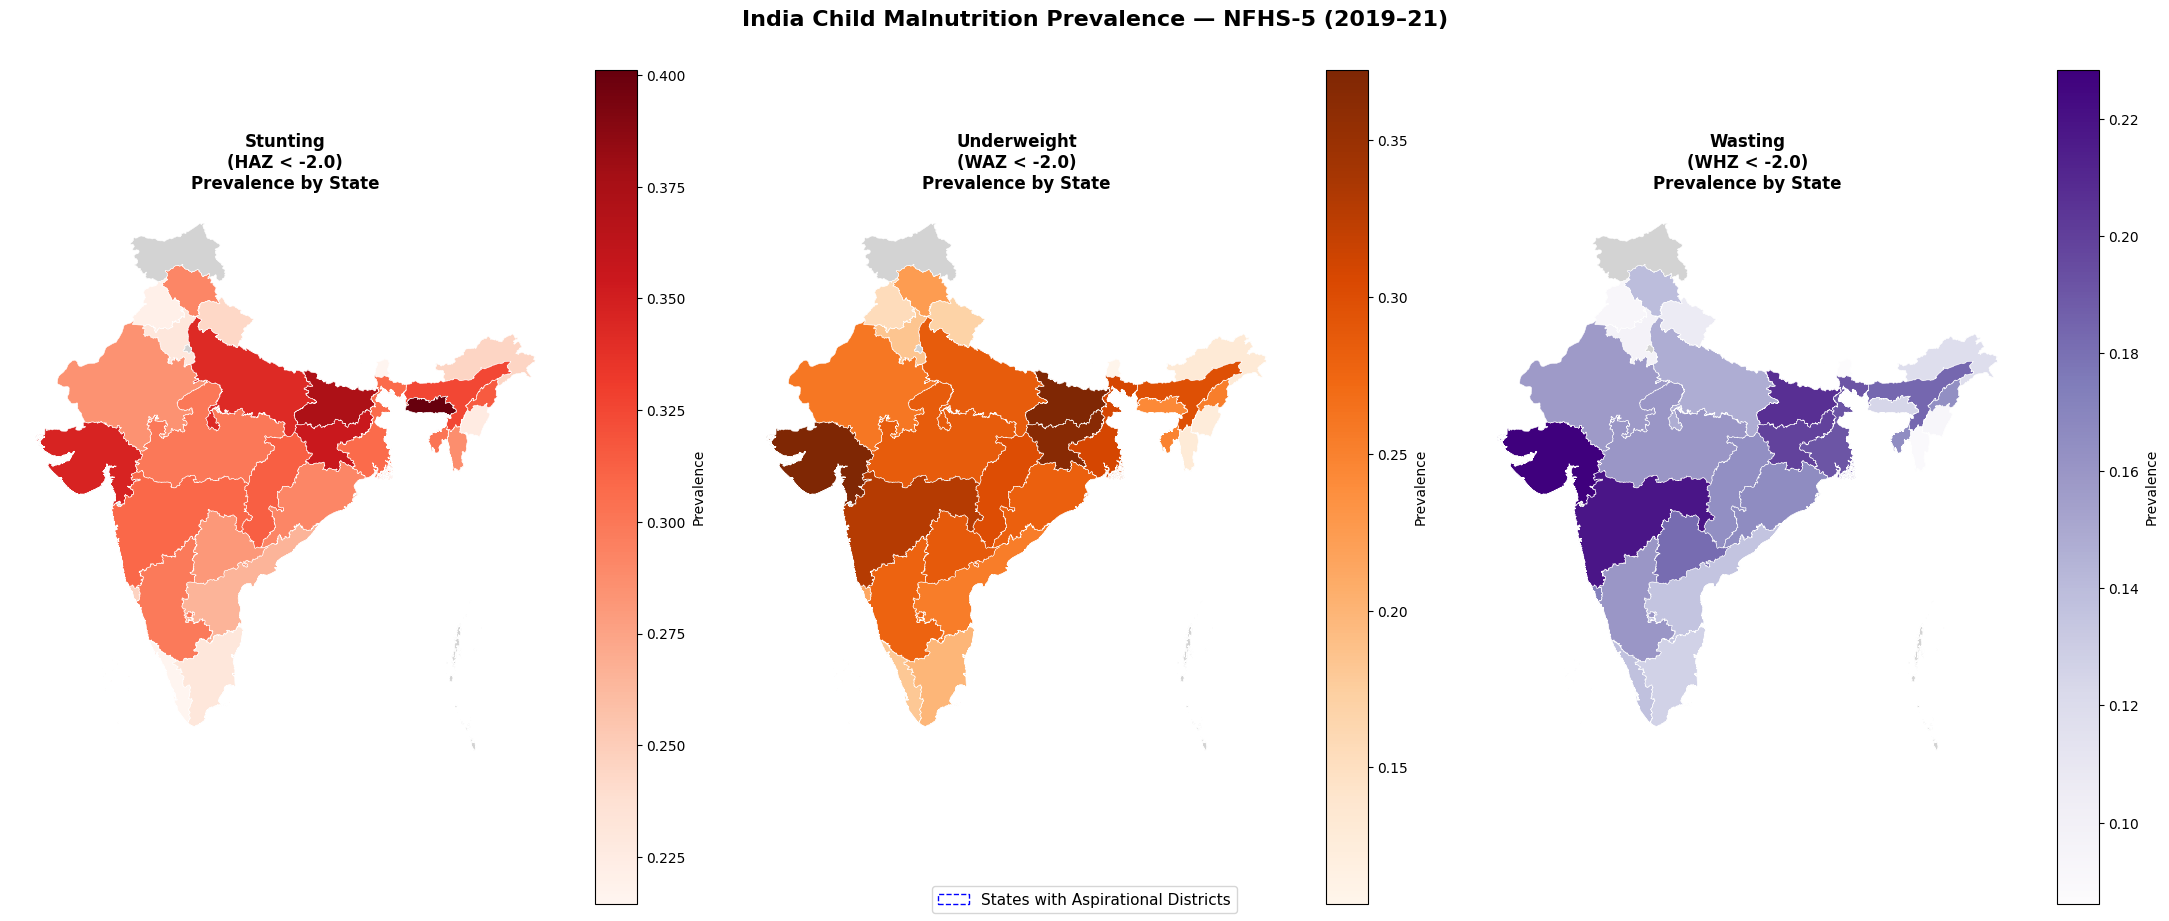

Saved: /workspaces/malnutrisense/reports/figures/india_malnutrition_choropleth.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(22, 9))

plot_configs = [
    ("stunting_prev", "Stunting\n(HAZ < -2.0)", "Reds"),
    ("underweight_prev", "Underweight\n(WAZ < -2.0)", "Oranges"),
    ("wasting_prev", "Wasting\n(WHZ < -2.0)", "Purples"),
]

india_states = districts.dissolve(by="NAME_1", aggfunc="first").reset_index()

state_code_map = {
    1: "Jammu And Kashmir", 2: "Himachal Pradesh", 3: "Punjab",
    4: "Chandigarh", 5: "Uttarakhand", 6: "Haryana",
    7: "Delhi", 8: "Rajasthan", 9: "Uttar Pradesh",
    10: "Bihar", 11: "Sikkim", 12: "Arunachal Pradesh",
    13: "Nagaland", 14: "Manipur", 15: "Mizoram",
    16: "Tripura", 17: "Meghalaya", 18: "Assam",
    19: "West Bengal", 20: "Jharkhand", 21: "Odisha",
    22: "Chhattisgarh", 23: "Madhya Pradesh", 24: "Gujarat",
    25: "Daman And Diu", 26: "Dadra And Nagar Haveli", 27: "Maharashtra",
    28: "Andhra Pradesh", 29: "Karnataka", 30: "Goa",
    31: "Lakshadweep", 32: "Kerala", 33: "Tamil Nadu",
    34: "Puducherry", 35: "Andaman And Nicobar Islands", 36: "Telangana",
}
state_stats = state_stats.copy()
state_stats["state_name"] = pd.to_numeric(state_stats["V024"], errors="coerce").map(state_code_map)

valid_state_stats = state_stats.dropna(subset=["state_name"])
india_states = india_states.merge(
    valid_state_stats[["state_name", "stunting_prev", "underweight_prev", "wasting_prev", "is_aspirational"]],
    left_on="NAME_1",
    right_on="state_name",
    how="left",
)

for ax, (col, title, cmap) in zip(axes, plot_configs):
    india_states.plot(
        column=col,
        cmap=cmap,
        legend=True,
        legend_kwds={"label": "Prevalence", "orientation": "vertical"},
        missing_kwds={"color": "lightgrey", "label": "No data"},
        ax=ax,
        edgecolor="white",
        linewidth=0.4,
    )
    asp_states = india_states[india_states["is_aspirational"] == 1]
    if not asp_states.empty:
        asp_states.boundary.plot(ax=ax, color="blue", linewidth=1.2, linestyle="--")

    ax.set_title(f"{title}\nPrevalence by State", fontweight="bold", fontsize=12)
    ax.axis("off")

asp_patch = mpatches.Patch(edgecolor="blue", facecolor="none", linestyle="--", label="States with Aspirational Districts")
fig.legend(handles=[asp_patch], loc="lower center", fontsize=11)

plt.suptitle("India Child Malnutrition Prevalence — NFHS-5 (2019–21)", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()

out_path = FIGURES_DIR / "india_malnutrition_choropleth.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")